In [ ]:

%pip install pandas numpy matplotlib scikit-learn seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
file_path = "../375Milestone/Football_Player_Market_Value_Trajectories/transfermarkt_player_values.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head(3)) #this shows what a portion of the dataset looks like 
display(df.info())

Shape: (508, 36)


,player_id,name,age,nationality,position,position_group,current_club,league_name,current_value_eur,current_value_tier,peak_value_eur,peak_value_tier,peak_date,peak_club,age_at_peak,first_value_eur,first_date,last_value_eur,last_date,career_span_years,years_to_peak,value_cagr,value_to_peak_cagr,value_multiplier_x,post_peak_decline_pct,value_volatility,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,trajectory,is_at_peak,ever_100m,ever_50m,ever_10m,data_source,dataset_built_at
0,418560,Erling Haaland,25.0,Norway,€200.00m,Other,Norway,Premier League,200000000.0,World Class (100M+),200000000,World Class (100M+),2024-09-30,Manchester City,24,200000,2016-12-17,200000000,2025-12-08,8.97,7.78,1.1591,1.4290,1000.00,0.00,0.7018,1.6329,26,5,growing,0,1,1,1,Transfermarkt.com,2026-02-21
1,433177,Bukayo Saka,24.0,England,€130.00m,Other,England,Premier League,130000000.0,World Class (100M+),150000000,World Class (100M+),2024-12-15,Arsenal FC,23,7000000,2019-09-22,130000000,2025-12-08,6.21,5.23,0.6005,0.7964,21.43,13.33,0.5572,0.6972,22,1,growing,0,1,1,1,Transfermarkt.com,2026-02-21
2,357662,Declan Rice,27.0,England,€120.00m,Other,England,Premier League,120000000.0,World Class (100M+),120000000,World Class (100M+),2024-05-26,Arsenal FC,25,500000,2017-10-22,120000000,2025-12-08,8.13,6.59,0.9625,1.2963,240.00,0.00,0.5807,1.6100,24,2,growing,0,1,1,1,Transfermarkt.com,2026-02-21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   player_id              508 non-null    int64  
 1   name                   508 non-null    object 
 2   age                    501 non-null    float64
 3   nationality            501 non-null    object 
 4   position               508 non-null    object 
 5   position_group         508 non-null    object 
 6   current_club           508 non-null    object 
 7   league_name            508 non-null    object 
 8   current_value_eur      508 non-null    float64
 9   current_value_tier     508 non-null    object 
 10  peak_value_eur         508 non-null    int64  
 11  peak_value_tier        508 non-null    object 
 12  peak_date              508 non-null    object 
 13  peak_club              508 non-null    object 
 14  age_at_peak            508 non-null    int64  
 15  first_

None

In [ ]:
TARGET = "current_value_eur"

df_model = df.copy()

league_tier_map = {
    "Premier League": 5,
    "LaLiga": 5,
    "Bundesliga": 5,
    "Serie A": 5,
    "Ligue 1": 5,
    "Primeira Liga": 4,
    "Eredivisie": 4,
    "Jupiler Pro League": 3,
    "Süper Lig": 3,
    "Championship": 2
}

#fills all null values
df_model["league_tier_score"] = df_model["league_name"].map(league_tier_map).fillna(3)

df_model["valuation_points_per_year"] = (
    df_model["num_valuation_points"] / df_model["career_span_years"].replace(0, np.nan)
).fillna(0)


##all features that are not super important or cause leakage in data, leading to poor predictions 
drop_cols = [
    TARGET,
    "current_value_tier",
    "player_id",
    "name",
    "data_source",
    "dataset_built_at",
    "position",
    "last_value_eur", "last_date",
    "peak_value_eur", "peak_date", "peak_value_tier", "peak_club",
    "is_at_peak", "trajectory",
    "ever_100m", "ever_50m", "ever_10m"
]

X = df_model.drop(columns=drop_cols, errors="ignore")
y = df_model[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Dropped leakage-prone columns present in source:")
print([c for c in drop_cols if c in df_model.columns])
print("Target summary:")

#information on data set. 
display(y.describe())

X shape: (508, 20)
y shape: (508,)
Dropped leakage-prone columns present in source:
['current_value_eur', 'current_value_tier', 'player_id', 'name', 'data_source', 'dataset_built_at', 'position', 'last_value_eur', 'last_date', 'peak_value_eur', 'peak_date', 'peak_value_tier', 'peak_club', 'is_at_peak', 'trajectory', 'ever_100m', 'ever_50m', 'ever_10m']
Target summary:


count    5.080000e+02
mean     3.686693e+07
std      2.770602e+07
min      3.000000e+05
25%      2.000000e+07
50%      2.800000e+07
75%      4.500000e+07
max      2.000000e+08
Name: current_value_eur, dtype: float64

In [ ]:
missing_count = X.isna().sum().sort_values(ascending=False)
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})

print("Columns with missing values:")
display(missing_table[missing_table["missing_count"] > 0])

Columns with missing values:


,missing_count,missing_pct
age,7,1.38
nationality,7,1.38


In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print("Sample numeric:", num_cols[:10])
print("Sample categorical:", cat_cols[:10])

Numeric columns: 15
Categorical columns: 5
Sample numeric: ['age', 'age_at_peak', 'first_value_eur', 'career_span_years', 'years_to_peak', 'value_cagr', 'value_to_peak_cagr', 'value_multiplier_x', 'post_peak_decline_pct', 'value_volatility']
Sample categorical: ['nationality', 'position_group', 'current_club', 'league_name', 'first_date']


In [ ]:
#this is where feature transformation happens. -  standard scalarer for numerical values and one hot encoding for categorical values. 

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #fills in any missing values with the median of the column
    ("scaler", StandardScaler())  # applicable for linear/distance models
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #fills in any missing values with the most frequent value of the column
    ("onehot", OneHotEncoder(handle_unknown="ignore")) #this is used to convert the categorical variables into numerical variables
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols), #this is used to scale the numerical variables
        ("cat", categorical_preprocess, cat_cols) #this is used to convert the categorical variables into numerical variables
    ]
)

print("Preprocessor created (median/mode imputation + OHE + scaling).")

Preprocessor created (median/mode imputation + OHE + scaling).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (406, 442)
Processed test shape: (102, 442)


['age', 'age_at_peak', 'first_value_eur', 'career_span_years', 'years_to_peak', 'value_cagr', 'value_to_peak_cagr', 'value_multiplier_x', 'post_peak_decline_pct', 'value_volatility', 'mean_yoy_growth_rate', 'num_valuation_points', 'num_clubs_career', 'league_tier_score', 'valuation_points_per_year']


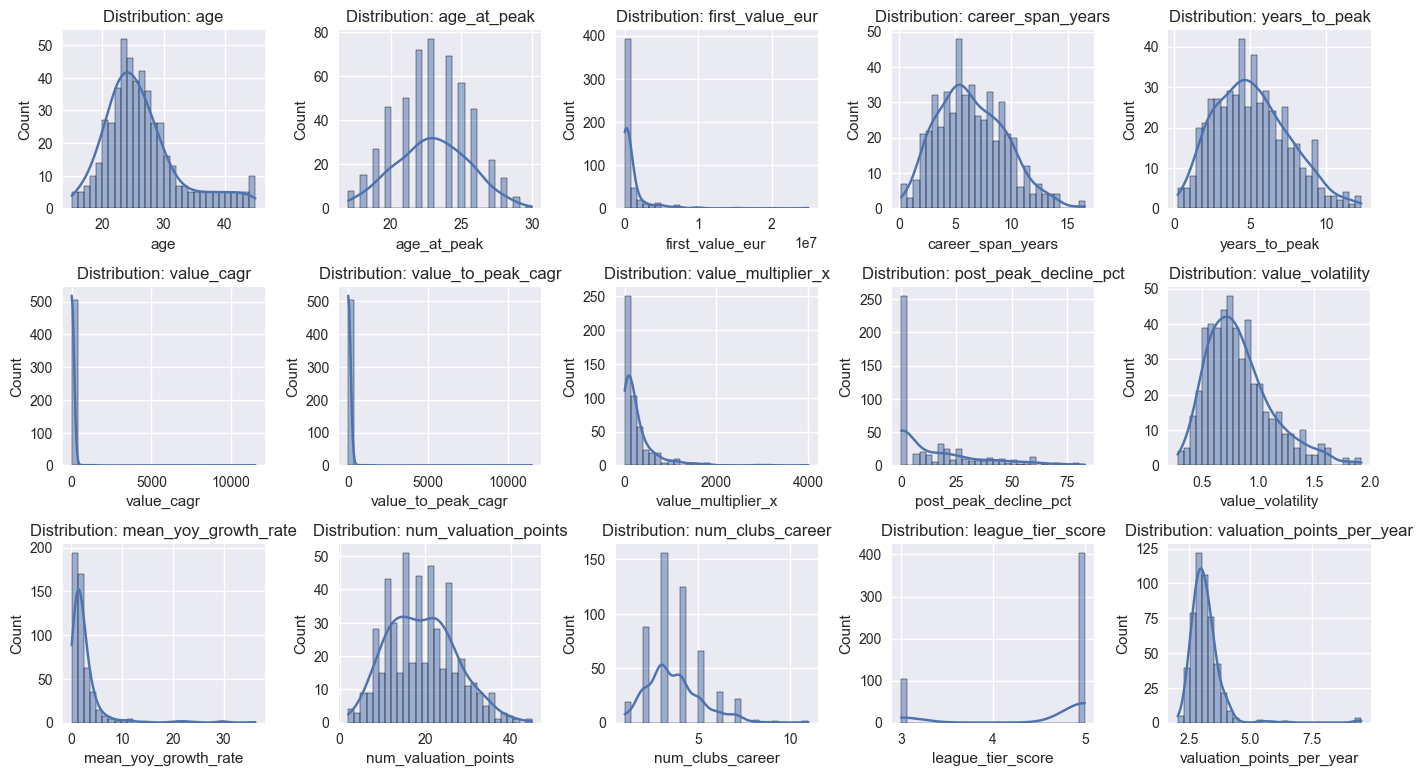

In [ ]:
plot_cols = num_cols  # choose first 9 numeric cols (or manually pick meaningful ones)
print(num_cols)
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    sns.histplot(df_model[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution: {col}")

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)  

plt.tight_layout()
plt.show()

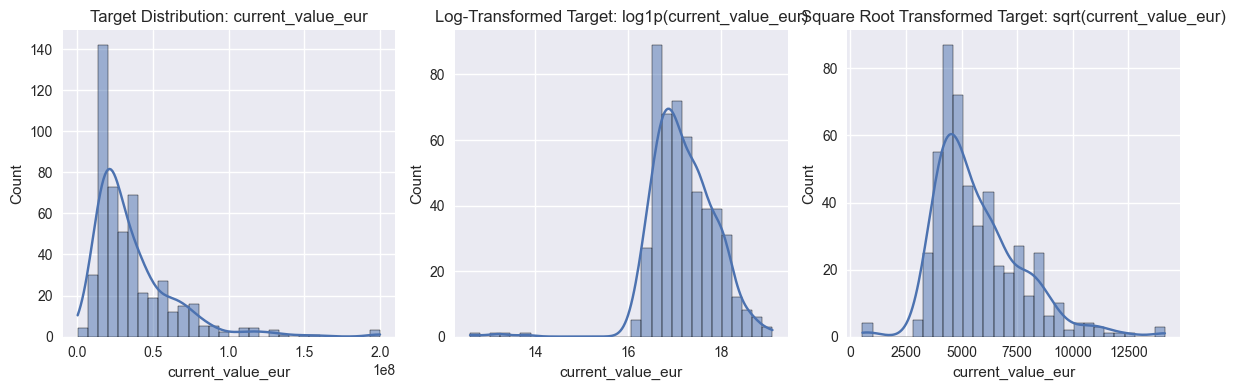

Target skewness (raw): 2.405
Target skewness (log1p): -1.064
Target skewness (sqrt): 1.147


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(y, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Target Distribution: current_value_eur")

sns.histplot(np.log1p(y), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Target: log1p(current_value_eur)")

sns.histplot(np.sqrt(y), bins=30, kde=True, ax=axes[2])
axes[2].set_title("Square Root Transformed Target: sqrt(current_value_eur)")


plt.tight_layout()
plt.show()

print("Target skewness (raw):", y.skew().round(3))
print("Target skewness (log1p):", np.log1p(y).skew().round(3))
print("Target skewness (sqrt):", np.sqrt(y).skew().round(3))



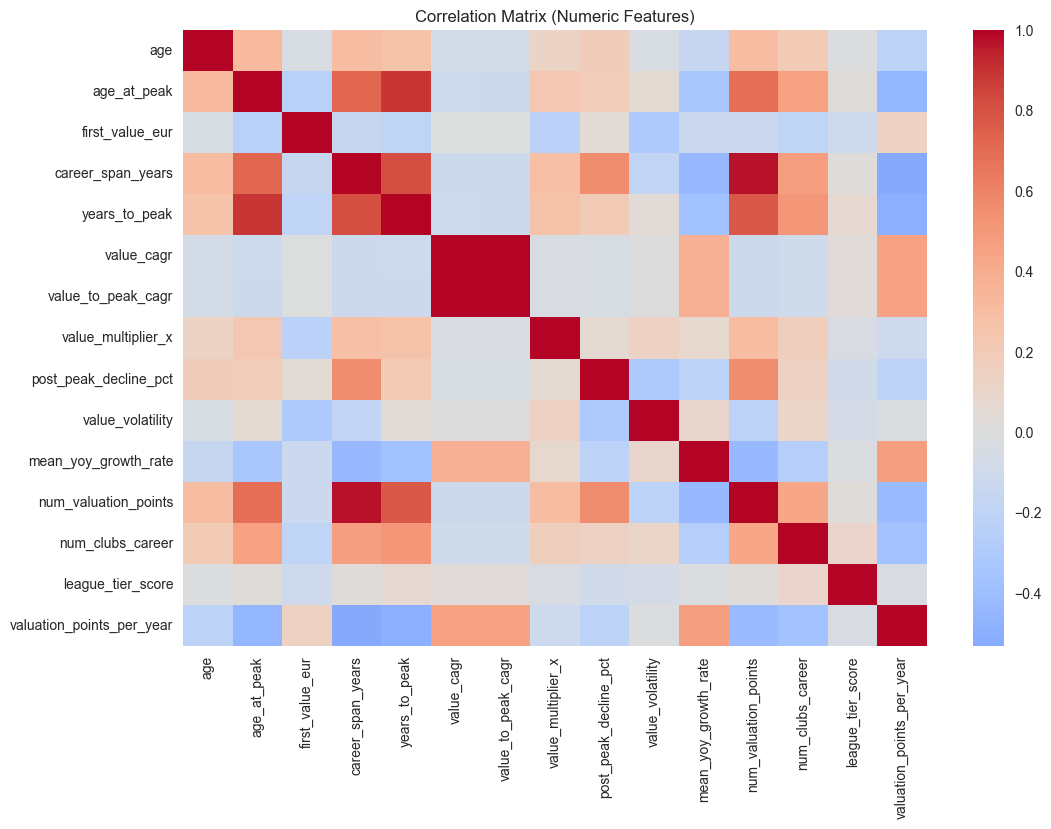

In [ ]:
#numeric features against eachother. 
corr = df_model[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [ ]:
# Only numeric features can be correlated directly this way - specific correlations against the target
target_corr = df_model[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Top positive correlations with target:")
display(target_corr.head(10).to_frame("corr_with_current_value_eur"))

print("Top negative correlations with target:")
display(target_corr.tail(10).to_frame("corr_with_current_value_eur"))


Top positive correlations with target:


,corr_with_current_value_eur
first_value_eur,0.272470
value_multiplier_x,0.243084
num_valuation_points,0.106924
years_to_peak,0.085963
valuation_points_per_year,0.066139
career_span_years,0.035129
age_at_peak,-0.005261
league_tier_score,-0.007621
value_cagr,-0.024022
value_to_peak_cagr,-0.024429


Top negative correlations with target:


,corr_with_current_value_eur
career_span_years,0.035129
age_at_peak,-0.005261
league_tier_score,-0.007621
value_cagr,-0.024022
value_to_peak_cagr,-0.024429
mean_yoy_growth_rate,-0.057069
num_clubs_career,-0.069203
age,-0.103900
value_volatility,-0.154668
post_peak_decline_pct,-0.201017


In [ ]:

print("Imbalance Note:")
print("- This is a regression task, so class imbalance is not directly applicable.")
print("- Instead, we inspect target distribution/skewness and quantiles.")
print("- If target is highly skewed, using log1p(target) can improve modeling stability.")

print("\nTarget quantiles:")
display(y.quantile([0.00, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]).to_frame("current_value_eur"))

Imbalance Note:
- This is a regression task, so class imbalance is not directly applicable.
- Instead, we inspect target distribution/skewness and quantiles.
- If target is highly skewed, using log1p(target) can improve modeling stability.

Target quantiles:


,current_value_eur
0.00,300000.0
0.25,20000000.0
0.50,28000000.0
0.75,45000000.0
0.90,70000000.0
0.95,85000000.0
0.99,139300000.0
1.00,200000000.0


Missing values were handled using median imputation for numeric variables and mode imputation for categorical variables.
Categorical features were transformed using one-hot encoding.
Numeric features were standardized using standard scaling (appropriate for linear/distance-based models).
We analyze feature distributions, target distribution, feature correlation matrix, and feature-target correlations.
Because this is a regression problem, class imbalance is not directly applicable; instead, target skewness and quantiles were analyzed.

## Training multiple models

## Ridge Regression

Ridge complete
Best params: {'model__alpha': 100.0}
Best Cross-Validation R2: 0.2069
Test R2: 0.3408
Test MAE: 17742824.93
Test RMSE: 26886084.74


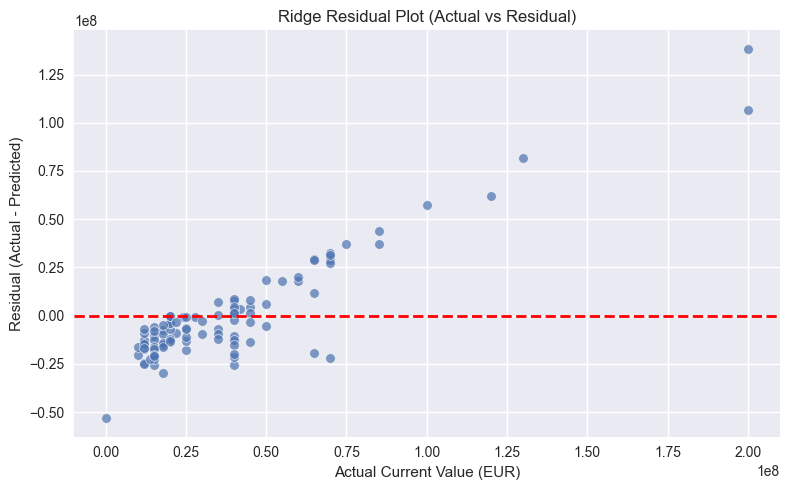

Ridge complete
Best params: {'model__alpha': 90}
Best Cross-Validation R2: 0.2076
Test R2: 0.3454
Test MAE: 17699504.65
Test RMSE: 26792216.00


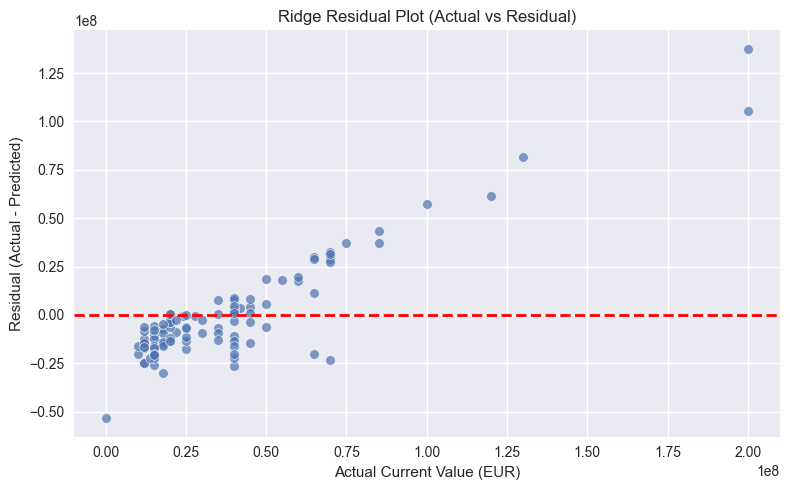

Ridge complete
Best params: {'model__alpha': 89}
Best Cross-Validation R2: 0.2076
Test R2: 0.3459
Test MAE: 17695293.05
Test RMSE: 26782798.98


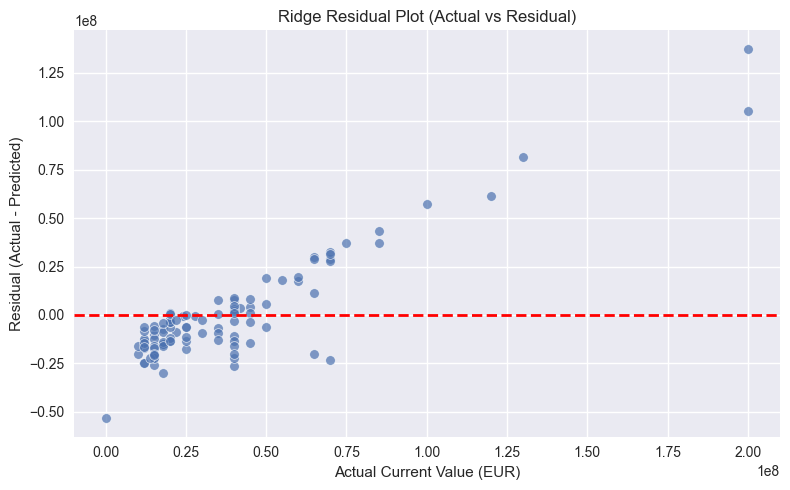

Ridge complete
Best params: {'model__alpha': 85}
Best Cross-Validation R2: 0.1667
Test R2: 0.3212
Test MAE: 16833596.36
Test RMSE: 27283505.89


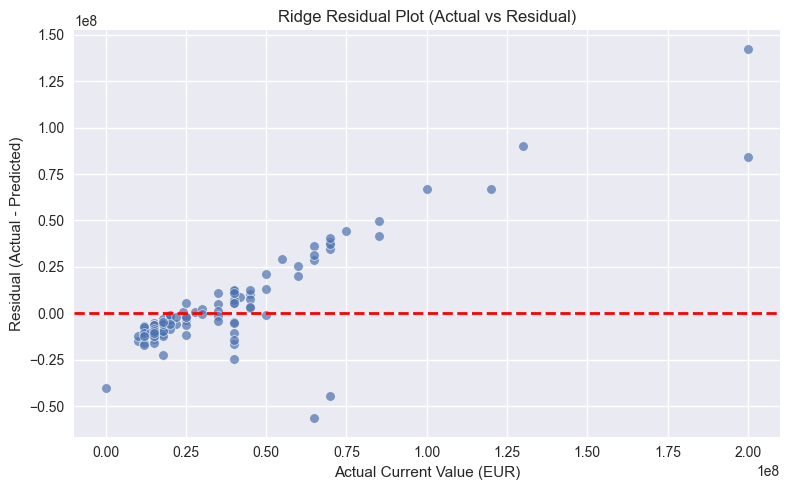


Add-on run (feature transforms + log target)
Ridge complete
Best params: {'model__alpha': 85}
Best Cross-Validation R2: 0.4617
Test R2: 0.4390
Test MAE: 13035511.48
Test RMSE: 24803912.66


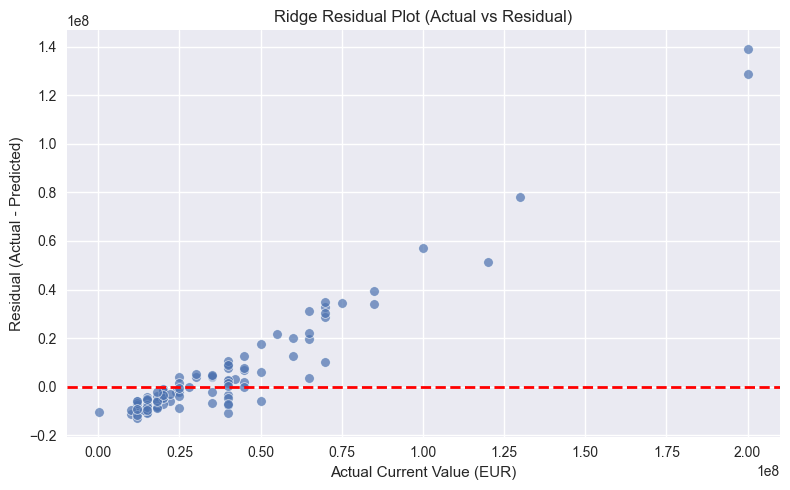


Feature-transform-only run
Ridge complete
Best params: {'model__alpha': 85}
Best Cross-Validation R2: 0.4047
Test R2: 0.4462
Test MAE: 14391417.34
Test RMSE: 24644019.70


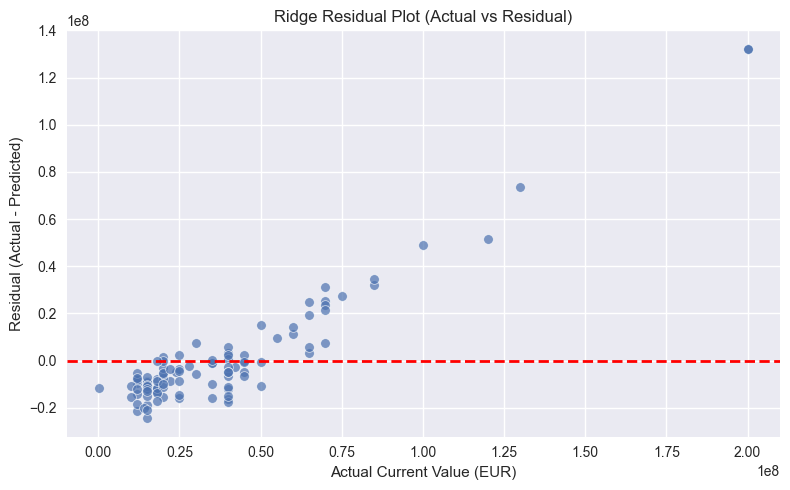

In [ ]:
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

results = []
best_estimators = {}

import json, time
DEBUG_LOG_PATH = "../375Milestone/.cursor/debug-d7188c.log"
def dbglog(run_id, hypothesis_id, location, message, data):
    payload = {
        "sessionId": "d7188c",
        "runId": run_id,
        "hypothesisId": hypothesis_id,
        "location": location,
        "message": message,
        "data": data,
        "timestamp": int(time.time() * 1000)
    }
    with open(DEBUG_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(payload) + "\n")

dbglog("pre-fix", "H2", "cell15:init", "results/best_estimators reset", {
    "results_len": len(results),
    "best_estimators_keys": list(best_estimators.keys())
})

def ridgeRegression(alphaValues, log=False, transform_features=False, label="Ridge"):
    cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

    y_train_model = y_train.copy()
    y_test_model = y_test.copy()
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

    if transform_features:
        skewed_cols = ["first_value_eur", "value_multiplier_x", "num_valuation_points"]
        for col in skewed_cols:
            if col in X_train_model.columns:
                X_train_model[col] = np.log1p(np.clip(X_train_model[col], a_min=0, a_max=None))
                X_test_model[col] = np.log1p(np.clip(X_test_model[col], a_min=0, a_max=None))

    ridge_pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", Ridge())
    ])

    ridge_param_grid = {"model__alpha": alphaValues}

    ridge_search = GridSearchCV(
        estimator=ridge_pipeline,
        param_grid=ridge_param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1
    )

    if log:
        y_train_model = np.log1p(y_train_model)

    ridge_search.fit(X_train_model, y_train_model)
    ridge_best = ridge_search.best_estimator_
    ridge_pred = ridge_best.predict(X_test_model)

    if log:
        ridge_pred = np.expm1(ridge_pred)

    ridge_metrics = {
        "model": label,
        "best_cv_r2": ridge_search.best_score_,
        "test_r2": r2_score(y_test_model, ridge_pred),
        "test_mae": mean_absolute_error(y_test_model, ridge_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_model, ridge_pred)),
        "best_params": ridge_search.best_params_,
        "ridge_pred": ridge_pred,
        "ridge_best": ridge_best,
        "transform_features": transform_features,
        "log_target": log
    }
    return ridge_metrics

def plotResidualPlots(y_test_model, ridge_pred):
    ridge_residuals = y_test_model - ridge_pred
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test_model, y=ridge_residuals, alpha=0.7)
    plt.axhline(0, color="red", linestyle="--", linewidth=2)
    plt.title("Ridge Residual Plot (Actual vs Residual)")
    plt.xlabel("Actual Current Value (EUR)")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.show()

def printMetrics(ridge_metrics):
    print("Ridge complete")
    print("Best params:", ridge_metrics["best_params"])
    print(f"Best Cross-Validation R2: {ridge_metrics['best_cv_r2']:.4f}")
    print(f"Test R2: {ridge_metrics['test_r2']:.4f}")
    print(f"Test MAE: {ridge_metrics['test_mae']:.2f}")
    print(f"Test RMSE: {ridge_metrics['test_rmse']:.2f}")



''' ridge alpha 1'''
alphaValues = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_metrics = ridgeRegression(alphaValues, label="Ridge_CoarseAlpha")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
printMetrics(ridge_metrics)

plotResidualPlots(y_test, ridge_metrics["ridge_pred"])

'''ridge alpha slightly tighter'''

alphaValues = [80,90, 100.0, 110, 120]
ridge_metrics = ridgeRegression(alphaValues, label="Ridge_MidAlpha")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
printMetrics(ridge_metrics)

plotResidualPlots(y_test, ridge_metrics["ridge_pred"])

''' ridge alpha much tighter'''

alphaValues = [85,87,89,91,93]
ridge_metrics = ridgeRegression(alphaValues, label="Ridge_TightAlpha")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
printMetrics(ridge_metrics)

plotResidualPlots(y_test, ridge_metrics["ridge_pred"])




''' try training with log1p(y) based off of our distribution visuals earlier  - trains on log1p(y) and predicts on original y'''
alphaValues = [85,87,89,91,93]
ridge_metrics = ridgeRegression(alphaValues, log=True, label="Ridge_LogTarget")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
printMetrics(ridge_metrics)
plotResidualPlots(y_test, ridge_metrics["ridge_pred"])

''' add-on experiment: transform skewed predictors + log target - also transforms input features as well '''
alphaValues = [85,87,89,91,93]
ridge_metrics = ridgeRegression(alphaValues, log=True, transform_features=True, label="Ridge_AddOn")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
print("\nAdd-on run (feature transforms + log target)")
printMetrics(ridge_metrics)
plotResidualPlots(y_test, ridge_metrics["ridge_pred"])

''' just this experiment: transform skewed predictors only - only transforms input features, but keeps target on the original scale. '''
alphaValues = [85,87,89,91,93]
ridge_metrics = ridgeRegression(alphaValues, log=False, transform_features=True, label="Ridge_FeatureOnly")
results.append({k: ridge_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators[ridge_metrics["model"]] = ridge_metrics["ridge_best"]
print("\nFeature-transform-only run")
printMetrics(ridge_metrics)
plotResidualPlots(y_test, ridge_metrics["ridge_pred"])








## Random Forest


Experiment 1: Baseline RF
Random Forest complete
Best params: {'model__max_depth': 15, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best Cross-Validation R2: 0.3813
Test R2: 0.3582
Test MAE: 15279988.11
Test RMSE: 26529229.05


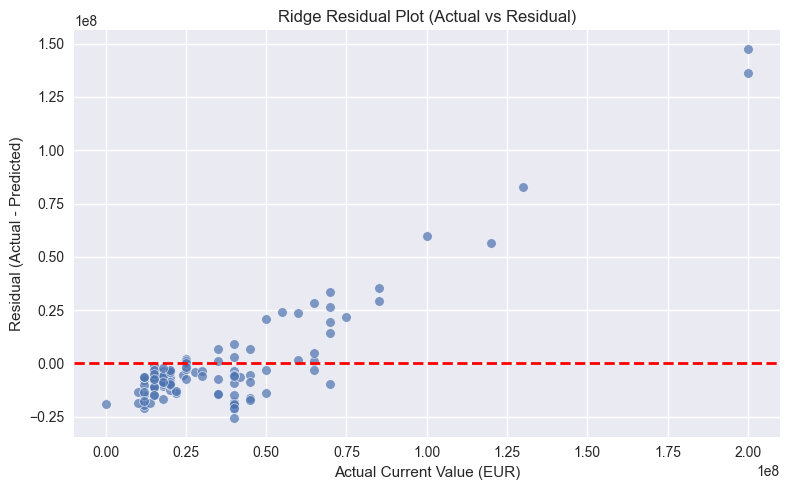


Experiment 2: Tuned RF
Random Forest complete
Best params: {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 800}
Best Cross-Validation R2: 0.3925
Test R2: 0.3717
Test MAE: 14673450.02
Test RMSE: 26249494.55


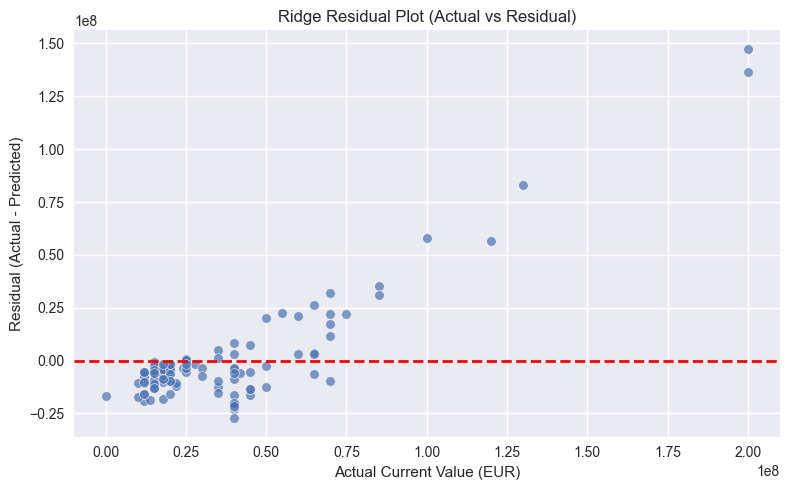


Experiment 3: Add-on RF (feature transforms + log target)
Random Forest complete
Best params: {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best Cross-Validation R2: 0.4959
Test R2: 0.3334
Test MAE: 13704665.73
Test RMSE: 27036124.37


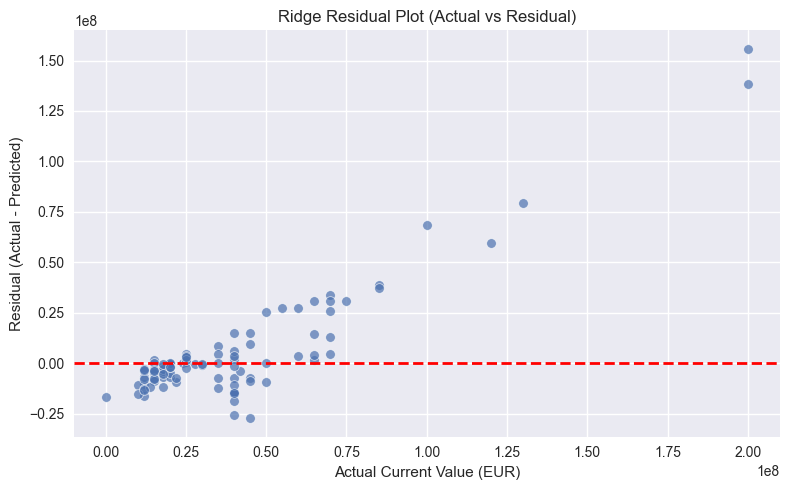

In [ ]:
def randomForestRegression(param_grid, log=False, transform_features=False, label="RandomForest"):
    cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

    y_train_model = y_train.copy()
    y_test_model = y_test.copy()

    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

    if transform_features:
        skewed_cols = ["first_value_eur", "value_multiplier_x", "num_valuation_points"]
        for col in skewed_cols:
            if col in X_train_model.columns:
                X_train_model[col] = np.log1p(np.clip(X_train_model[col], a_min=0, a_max=None))
                X_test_model[col] = np.log1p(np.clip(X_test_model[col], a_min=0, a_max=None))

    rf_pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    rf_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1
    )

    if log:
        y_train_model = np.log1p(y_train_model)

    rf_search.fit(X_train_model, y_train_model)
    rf_best = rf_search.best_estimator_
    rf_pred = rf_best.predict(X_test_model)

    if log:
        rf_pred = np.expm1(rf_pred)

    rf_metrics = {
        "model": label,
        "best_cv_r2": rf_search.best_score_,
        "test_r2": r2_score(y_test_model, rf_pred),
        "test_mae": mean_absolute_error(y_test_model, rf_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_model, rf_pred)),
        "best_params": rf_search.best_params_,
        "rf_pred": rf_pred,
        "rf_best": rf_best,
        "transform_features": transform_features,
        "log_target": log
    }
    return rf_metrics


def printRFMetrics(rf_metrics):
    print("Random Forest complete")
    print("Best params:", rf_metrics["best_params"])
    print(f"Best Cross-Validation R2: {rf_metrics['best_cv_r2']:.4f}")
    print(f"Test R2: {rf_metrics['test_r2']:.4f}")
    print(f"Test MAE: {rf_metrics['test_mae']:.2f}")
    print(f"Test RMSE: {rf_metrics['test_rmse']:.2f}")


# Experiment 1: baseline RF grid
rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 15, 25],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.5]
}

rf_metrics = randomForestRegression(rf_param_grid, log=False, transform_features=False, label="RandomForest_Baseline")
results.append({k: rf_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["RandomForest"] = rf_metrics["rf_best"]
print("\nExperiment 1: Baseline RF")
printRFMetrics(rf_metrics)
plotResidualPlots(y_test, rf_metrics["rf_pred"])


# Experiment 2: stronger RF tuning 
rf_param_grid = {
    "model__n_estimators": [500, 800],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.7],
    "model__bootstrap": [True]
}

rf_metrics = randomForestRegression(rf_param_grid, log=False, transform_features=False, label="RandomForest_Tuned")
results.append({k: rf_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["RandomForest"] = rf_metrics["rf_best"]
print("\nExperiment 2: Tuned RF")
printRFMetrics(rf_metrics)
plotResidualPlots(y_test, rf_metrics["rf_pred"])


# Experiment 3: add-on (feature transforms + log target)
rf_param_grid = {
    "model__n_estimators": [500, 800],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.7],
    "model__bootstrap": [True]
}

rf_metrics = randomForestRegression(rf_param_grid, log=True, transform_features=True, label="RandomForest_AddOn")
results.append({k: rf_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["RandomForest"] = rf_metrics["rf_best"]
print("\nExperiment 3: Add-on RF (feature transforms + log target)")
printRFMetrics(rf_metrics)
plotResidualPlots(y_test, rf_metrics["rf_pred"])



Experiment 1: Baseline MLP
Neural Network complete
Best params: {'model__alpha': 0.01, 'model__hidden_layer_sizes': (128,), 'model__learning_rate_init': 0.001}
Best Cross-Validation R2: -2.1280
Test R2: -1.3075
Test MAE: 37865684.71
Test RMSE: 50303011.00


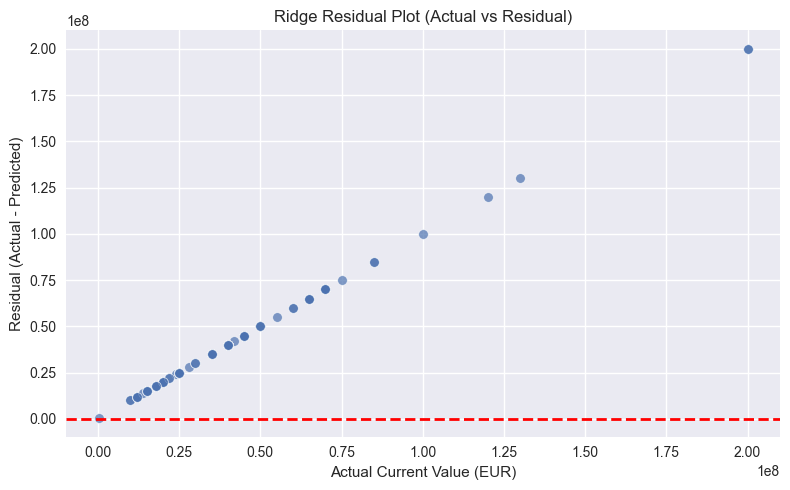


Experiment 2: Tuned MLP
Neural Network complete
Best params: {'model__activation': 'tanh', 'model__alpha': 0.05, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.001}
Best Cross-Validation R2: -2.1280
Test R2: -1.3075
Test MAE: 37865681.30
Test RMSE: 50303008.18


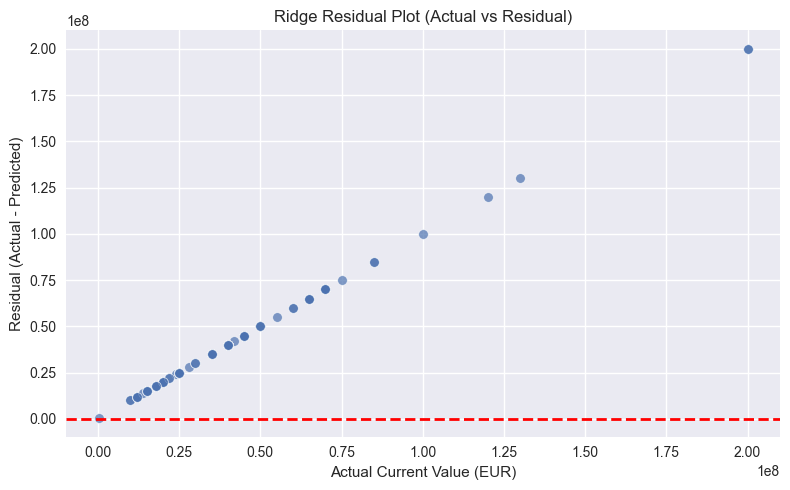

/Users/jainamshah/Desktop/375/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/jainamshah/Desktop/375/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/jainamshah/Desktop/375/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/jainamshah/Desktop/375/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1200) reached and the optimization hasn't converged ye


Experiment 3: Add-on MLP (feature transforms + log target)
Neural Network complete
Best params: {'model__activation': 'tanh', 'model__alpha': 0.05, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.0003}
Best Cross-Validation R2: -0.5433
Test R2: 0.0146
Test MAE: 19320258.19
Test RMSE: 32871931.44


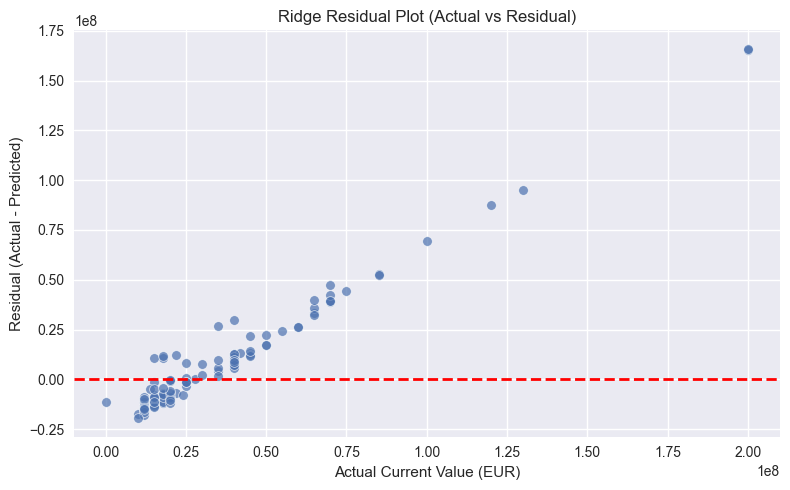

In [ ]:
def neuralNetworkRegression(param_grid, log=False, transform_features=False, label="NeuralNetwork"):
    cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

    y_train_model = y_train.copy()
    y_test_model = y_test.copy()

    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

    if transform_features:
        skewed_cols = ["first_value_eur", "value_multiplier_x", "num_valuation_points"]
        for col in skewed_cols:
            if col in X_train_model.columns:
                X_train_model[col] = np.log1p(np.clip(X_train_model[col], a_min=0, a_max=None))
                X_test_model[col] = np.log1p(np.clip(X_test_model[col], a_min=0, a_max=None))

    mlp_pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", MLPRegressor(random_state=42, max_iter=1200, early_stopping=True))
    ])

    mlp_search = GridSearchCV(
        estimator=mlp_pipeline,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1
    )

    if log:
        y_train_model = np.log1p(y_train_model)

    mlp_search.fit(X_train_model, y_train_model)
    mlp_best = mlp_search.best_estimator_
    mlp_pred = mlp_best.predict(X_test_model)

    if log:
        mlp_pred = np.expm1(mlp_pred)

    mlp_metrics = {
        "model": label,
        "best_cv_r2": mlp_search.best_score_,
        "test_r2": r2_score(y_test_model, mlp_pred),
        "test_mae": mean_absolute_error(y_test_model, mlp_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_model, mlp_pred)),
        "best_params": mlp_search.best_params_,
        "mlp_pred": mlp_pred,
        "mlp_best": mlp_best,
        "transform_features": transform_features,
        "log_target": log
    }
    return mlp_metrics


def printMLPMetrics(mlp_metrics):
    print("Neural Network complete")
    print("Best params:", mlp_metrics["best_params"])
    print(f"Best Cross-Validation R2: {mlp_metrics['best_cv_r2']:.4f}")
    print(f"Test R2: {mlp_metrics['test_r2']:.4f}")
    print(f"Test MAE: {mlp_metrics['test_mae']:.2f}")
    print(f"Test RMSE: {mlp_metrics['test_rmse']:.2f}")


# Experiment 1: baseline MLP grid
mlp_param_grid = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha": [1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-3, 5e-4]
}

mlp_metrics = neuralNetworkRegression(mlp_param_grid, log=False, transform_features=False, label="NeuralNetwork_Baseline")
results.append({k: mlp_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["NeuralNetwork"] = mlp_metrics["mlp_best"]
print("\nExperiment 1: Baseline MLP")
printMLPMetrics(mlp_metrics)
plotResidualPlots(y_test, mlp_metrics["mlp_pred"])


# Experiment 2: tuned MLP grid 
mlp_param_grid = {
    "model__hidden_layer_sizes": [(128,), (128, 64), (64, 32)],
    "model__alpha": [1e-3, 1e-2, 5e-2],
    "model__learning_rate_init": [1e-3, 3e-4],
    "model__activation": ["relu", "tanh"]
}

mlp_metrics = neuralNetworkRegression(mlp_param_grid, log=False, transform_features=False, label="NeuralNetwork_Tuned")
results.append({k: mlp_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["NeuralNetwork"] = mlp_metrics["mlp_best"]
print("\nExperiment 2: Tuned MLP")
printMLPMetrics(mlp_metrics)
plotResidualPlots(y_test, mlp_metrics["mlp_pred"])


# Experiment 3: add-on (feature transforms + log target)
mlp_param_grid = {
    "model__hidden_layer_sizes": [(128,), (128, 64), (64, 32)],
    "model__alpha": [1e-3, 1e-2, 5e-2],
    "model__learning_rate_init": [1e-3, 3e-4],
    "model__activation": ["relu", "tanh"]
}

mlp_metrics = neuralNetworkRegression(mlp_param_grid, log=True, transform_features=True, label="NeuralNetwork_AddOn")
results.append({k: mlp_metrics[k] for k in ["model", "best_cv_r2", "test_r2", "test_mae", "test_rmse", "best_params"]})
best_estimators["NeuralNetwork"] = mlp_metrics["mlp_best"]
print("\nExperiment 3: Add-on MLP (feature transforms + log target)")
printMLPMetrics(mlp_metrics)
plotResidualPlots(y_test, mlp_metrics["mlp_pred"])


In [ ]:
baseline_pred_mean = np.full_like(y_test_model, y_train_model.mean(), dtype=float)
baseline_pred_median = np.full_like(y_test_model, y_train_model.median(), dtype=float)

baseline_rows = [
    {
        "model": "Baseline_Mean",
        "best_cv_r2": np.nan,
        "test_r2": r2_score(y_test_model, baseline_pred_mean),
        "test_mae": mean_absolute_error(y_test_model, baseline_pred_mean),
        "test_rmse": np.sqrt(mean_squared_error(y_test_model, baseline_pred_mean)),
        "best_params": "predict train mean"
    },
    {
        "model": "Baseline_Median",
        "best_cv_r2": np.nan,
        "test_r2": r2_score(y_test_model, baseline_pred_median),
        "test_mae": mean_absolute_error(y_test_model, baseline_pred_median),
        "test_rmse": np.sqrt(mean_squared_error(y_test_model, baseline_pred_median)),
        "best_params": "predict train median"
    }
]

results_df = pd.DataFrame(results + baseline_rows).sort_values("test_r2", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
final_model = best_estimators[best_model_name] if best_model_name in best_estimators else None

print("Best model:", best_model_name)
print("Best params:", results_df.iloc[0]["best_params"])

,model,best_cv_r2,test_r2,test_mae,test_rmse,best_params
5,Ridge_FeatureOnly,0.404692,0.446163,1.439142e+07,2.464402e+07,{'model__alpha': 85}
4,Ridge_AddOn,0.461716,0.438953,1.303551e+07,2.480391e+07,{'model__alpha': 85}
7,RandomForest_Tuned,0.392463,0.371652,1.467345e+07,2.624949e+07,"{'model__bootstrap': True, 'model__max_depth':..."
6,RandomForest_Baseline,0.381304,0.358188,1.527999e+07,2.652923e+07,"{'model__max_depth': 15, 'model__max_features'..."
2,Ridge_TightAlpha,0.207586,0.345860,1.769529e+07,2.678280e+07,{'model__alpha': 89}
1,Ridge_MidAlpha,0.207576,0.345400,1.769950e+07,2.679222e+07,{'model__alpha': 90}
0,Ridge_CoarseAlpha,0.206937,0.340805,1.774282e+07,2.688608e+07,{'model__alpha': 100.0}
8,RandomForest_AddOn,0.495868,0.333427,1.370467e+07,2.703612e+07,"{'model__bootstrap': True, 'model__max_depth':..."
3,Ridge_LogTarget,0.166670,0.321173,1.683360e+07,2.728351e+07,{'model__alpha': 85}
11,NeuralNetwork_AddOn,-0.543314,0.014608,1.932026e+07,3.287193e+07,"{'model__activation': 'tanh', 'model__alpha': ..."


Best model: Ridge_FeatureOnly
Best params: {'model__alpha': 85}


In [ ]:
from sklearn.metrics import r2_score

r2=r2_score(y_true,y_pred)
print("R2 Score: ",r2)

R2:  0.4461634055307062


In [37]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print("MAE: ", mae)

MAE:  14391417.34175371


In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true,y_pred))
print("RMSE: ", rmse)

RMSE:  24644019.697773788


In [42]:
ridge_model = ridge_metrics['ridge_best']
model = ridge_model.named_steps["model"]
feature_names = ridge_model.named_steps["prep"].get_feature_names_out()

coefficients = model.coef_

coef_df = pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":coefficients
})

coef_df = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
)

print(coef_df.head(15))

                             Feature   Coefficient
2               num__first_value_eur  1.293504e+07
7            num__value_multiplier_x  1.251019e+07
8         num__post_peak_decline_pct -7.174710e+06
134  cat__league_name_Premier League  6.328542e+06
11         num__num_valuation_points  4.983167e+06
1                   num__age_at_peak -2.845575e+06
4                 num__years_to_peak  2.694629e+06
133         cat__league_name_Ligue 1 -2.504481e+06
14    num__valuation_points_per_year  2.490922e+06
131      cat__league_name_Bundesliga -2.406918e+06
9              num__value_volatility -2.355555e+06
135         cat__league_name_Serie A -2.094362e+06
12             num__num_clubs_career -2.013253e+06
88         cat__current_club_England  1.981189e+06
30          cat__nationality_England  1.981189e+06


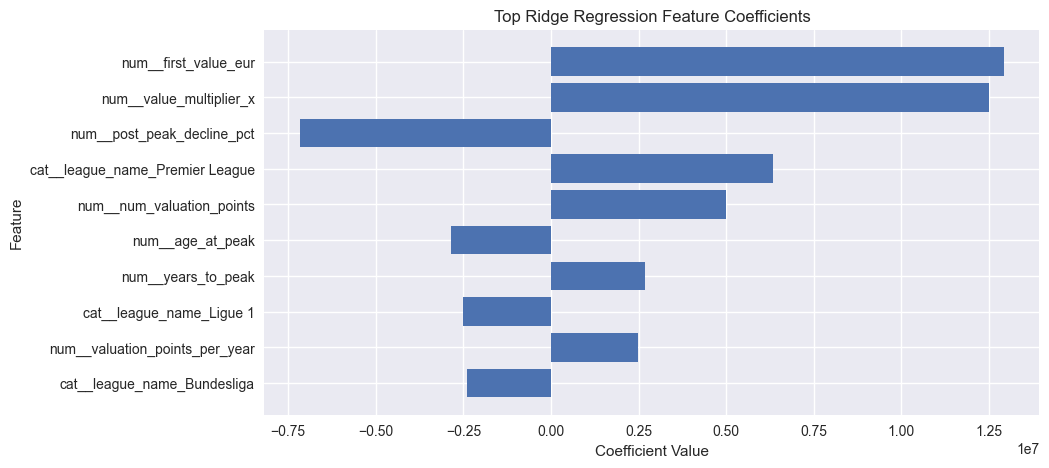

In [43]:
top_features = coef_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Ridge Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()